In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from chiricoca.config import setup_style

setup_style()

In [3]:
from pathlib import Path

DATA_PATH = Path("data") / "arenas-jazz"

In [4]:
!cat {DATA_PATH}/README.arenas-jazz

Jazz musicians network, part of the Koblenz Network Collection

This directory contains the TSV and related files of the arenas-jazz network:

This is the collaboration network between Jazz musicians.  Each node is a Jazz musician and an edge denotes that two musicians have played together in a band.  The data was collected in 2003. 


More information about the network is provided here: 
http://konect.uni-koblenz.de/networks/arenas-jazz

Files: 
    meta.arenas-jazz -- Metadata about the network 
    out.arenas-jazz -- The adjacency matrix of the network in space separated values format, with one edge per line
      The meaning of the columns in out.arenas-jazz are: 
        First column: ID of from node 
        Second column: ID of to node


Complete documentation about the file format can be found in the KONECT
handbook, in the section File Formats, available at:

http://konect.uni-koblenz.de/publications

All files are licensed under a Creative Commons Attribution-ShareAlike 2.0 G

In [5]:
!head {DATA_PATH}/out.arenas-jazz -n 10

% sym unweighted
1	10
1	11
1	12
1	13
1	14
1	15
1	16
1	17
1	18


In [6]:
edgelist = pd.read_csv(
    # ruta al archivo
    f"{DATA_PATH}/out.arenas-jazz",
    # noten que está separado por TABS, no por comas
    sep="\t",
    # no leer la primera línea
    skiprows=1,
    # no tiene nombres de columnas
    header=0,
    # estos son los nombres de las columnas
    names=["source", "target"],
)

edgelist

,source,target
0,1,11
1,1,12
2,1,13
3,1,14
4,1,15
...,...,...
2736,185,186
2737,187,188
2738,187,189
2739,188,189


In [7]:
import networkx as nx


network = nx.from_pandas_edgelist(edgelist, source='source', target='target')
network

In [21]:
from chiricoca.networks.stats import summary

summary(network)

{'nodes': 198,
 'edges': 2741,
 'avg_degree': 27.68686868686869,
 'density': 0.1405424806440035,
 'is_tree': False,
 'is_directed': False,
 'n_connected_components': 1}

In [23]:
pos = nx.spring_layout(network)
pos

{1: array([0.26915459, 0.01757989]),
 11: array([ 0.11172123, -0.03688987]),
 12: array([ 0.18656051, -0.05001646]),
 13: array([ 0.15645066, -0.03384122]),
 14: array([ 0.19037064, -0.03028117]),
 15: array([ 0.20036926, -0.0414323 ]),
 16: array([0.20170867, 0.09640429]),
 17: array([ 0.33249126, -0.00451959]),
 18: array([ 0.16327607, -0.03573685]),
 19: array([ 0.16108502, -0.02139825]),
 2: array([ 0.12853383, -0.09280571]),
 20: array([ 0.13691817, -0.02234282]),
 21: array([ 0.2472807 , -0.06261643]),
 22: array([0.31659565, 0.02361352]),
 23: array([ 0.13731957, -0.05361615]),
 24: array([ 0.14828222, -0.00327043]),
 3: array([ 0.25525022, -0.01082178]),
 4: array([ 0.25428022, -0.05092526]),
 5: array([0.30257387, 0.06234285]),
 6: array([ 0.27450951, -0.01078281]),
 7: array([0.12986116, 0.00793017]),
 8: array([0.21880665, 0.10678821]),
 9: array([ 0.21546537, -0.02089493]),
 120: array([-0.02061645,  0.01054023]),
 121: array([ 0.1451271 , -0.07455186]),
 122: array([ 0.041

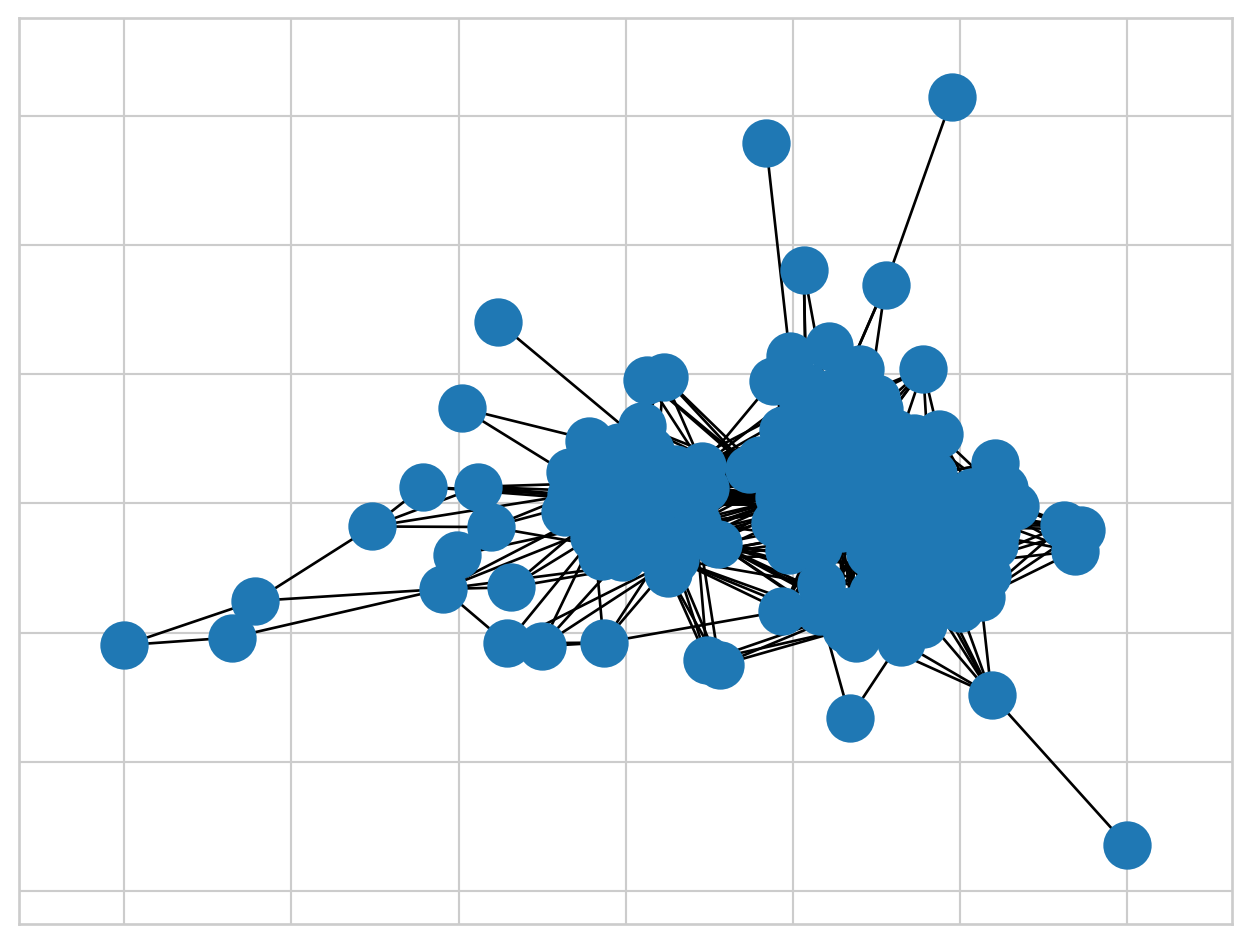

In [ ]:
nx.draw_networkx(network, pos=pos, with_labels=False)

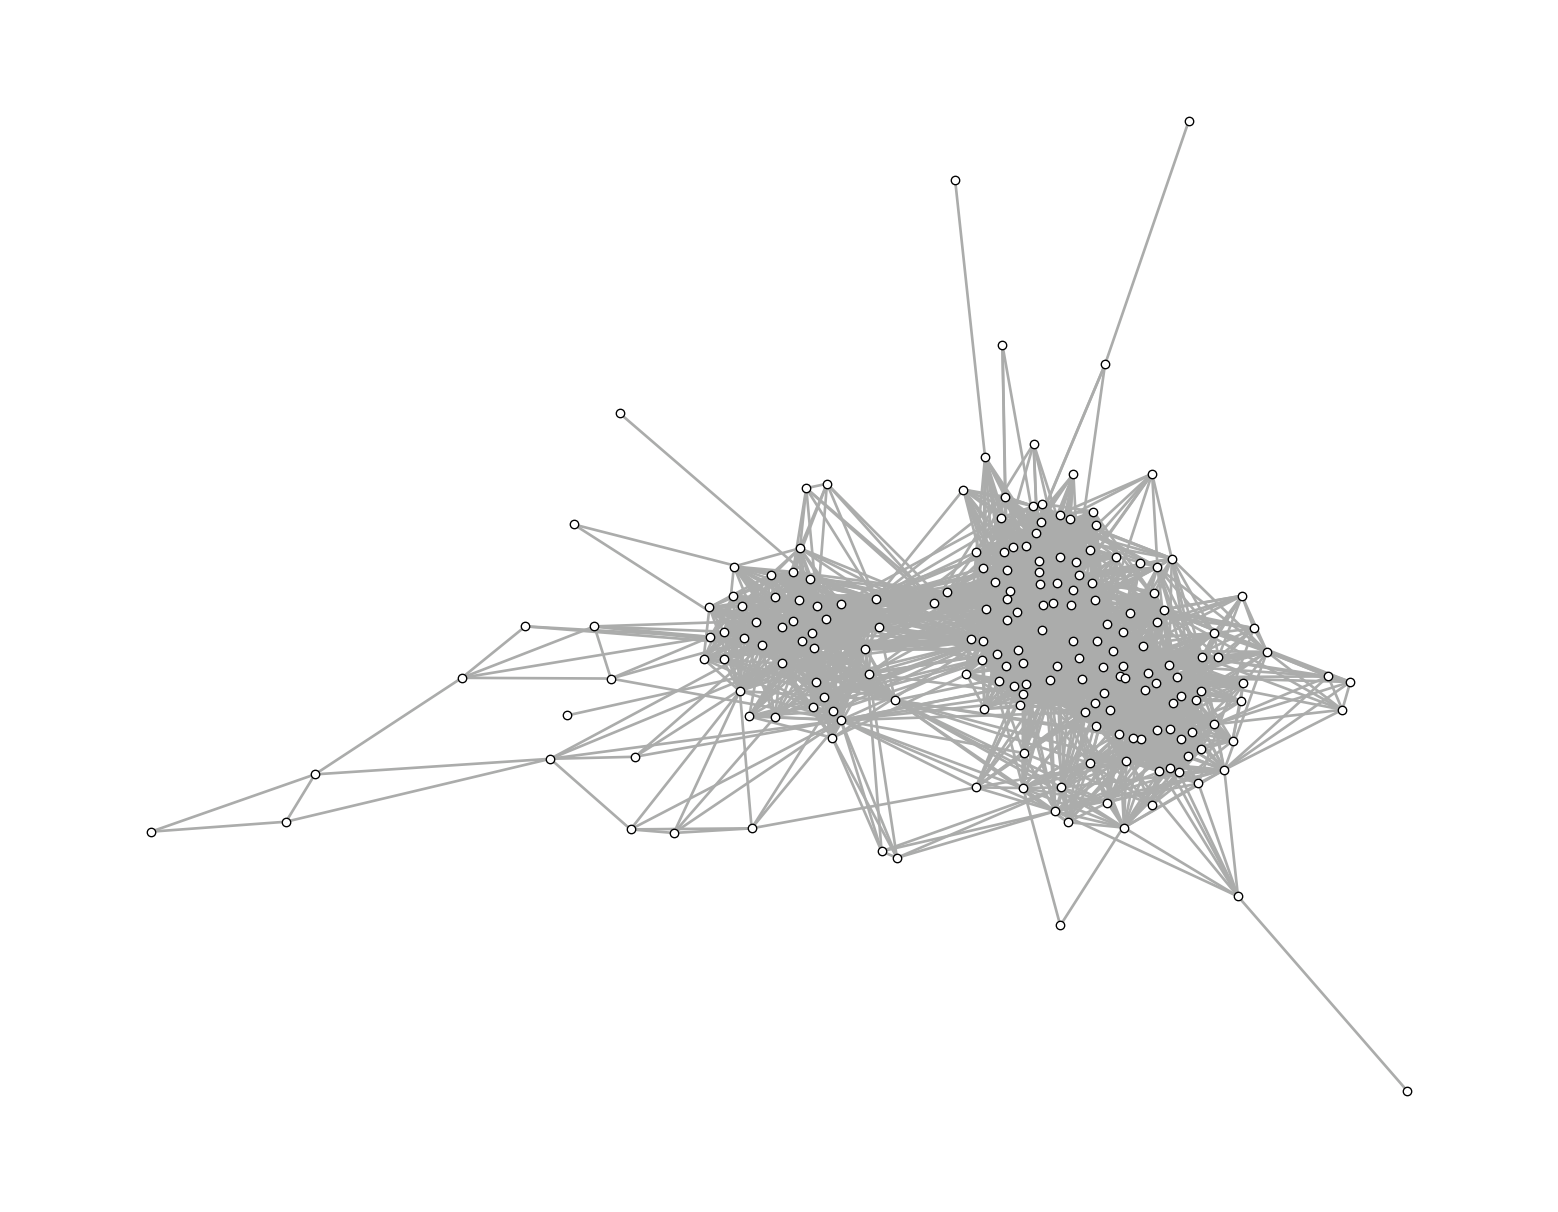

In [32]:
fig, ax = plt.subplots(figsize=(8,8))

nx.draw_networkx_edges(network, pos=pos, edge_color='#abacab')
nx.draw_networkx_nodes(network, pos=pos, node_color='white', edgecolors='black', linewidths=0.5, node_size=10)

ax.set_axis_off()
ax.set_aspect('equal')

In [33]:
edge_centrality = nx.edge_betweenness_centrality(network)
edge_centrality

{(1, 11): 0.0004648700239807522,
 (1, 12): 0.000381046378188169,
 (1, 13): 0.0009091728724481975,
 (1, 14): 0.0004009665676774126,
 (1, 15): 0.0004007014739853967,
 (1, 16): 0.0004035562298754716,
 (1, 17): 0.00021376854947290392,
 (1, 18): 0.0005082868775649843,
 (1, 19): 0.0006331040758881747,
 (1, 2): 0.00027640511572073396,
 (1, 20): 0.0007988379190731465,
 (1, 21): 0.00020132955318140269,
 (1, 22): 0.000570865205795838,
 (1, 23): 0.001696096051681044,
 (1, 24): 0.00040939652791532823,
 (1, 3): 0.0003096251210821663,
 (1, 4): 0.00020132955318140269,
 (1, 5): 0.00034699995279761475,
 (1, 6): 0.00010677346900369721,
 (1, 7): 0.0017279346814211317,
 (1, 8): 0.00035816452448343434,
 (1, 9): 0.0003715478388718714,
 (11, 2): 0.00023418567336455724,
 (11, 4): 0.0003731447961117814,
 (11, 6): 0.000468504107126793,
 (11, 7): 0.0004817230493903501,
 (11, 9): 0.00031984069838814457,
 (11, 101): 0.0003749731690348821,
 (11, 102): 0.00035734126268361824,
 (11, 103): 0.0004641953167388229,
 (11,

In [54]:
import numpy as np

edge_widths = [np.sqrt(edge_centrality[edge]) * 4 for edge in network.edges()]
edge_widths

[np.float64(0.08624337878174786),
 np.float64(0.0780816370922812),
 np.float64(0.12060997454261882),
 np.float64(0.08009659844736605),
 np.float64(0.08007011667136715),
 np.float64(0.08035483605861905),
 np.float64(0.05848330352815633),
 np.float64(0.09018087403124761),
 np.float64(0.10064623795359066),
 np.float64(0.06650174322175129),
 np.float64(0.11305488359717303),
 np.float64(0.05675625825318687),
 np.float64(0.0955711425731293),
 np.float64(0.16473474687174136),
 np.float64(0.08093419825169859),
 np.float64(0.07038467118140612),
 np.float64(0.05675625825318687),
 np.float64(0.07451173897287484),
 np.float64(0.04133249936864641),
 np.float64(0.16627373485532257),
 np.float64(0.07570094049438851),
 np.float64(0.07710230490685699),
 np.float64(0.0612125050445815),
 np.float64(0.07726782472535708),
 np.float64(0.08657982278815711),
 np.float64(0.08779276046602932),
 np.float64(0.07153636260119962),
 np.float64(0.0774568957844175),
 np.float64(0.07561388895525671),
 np.float64(0.0861

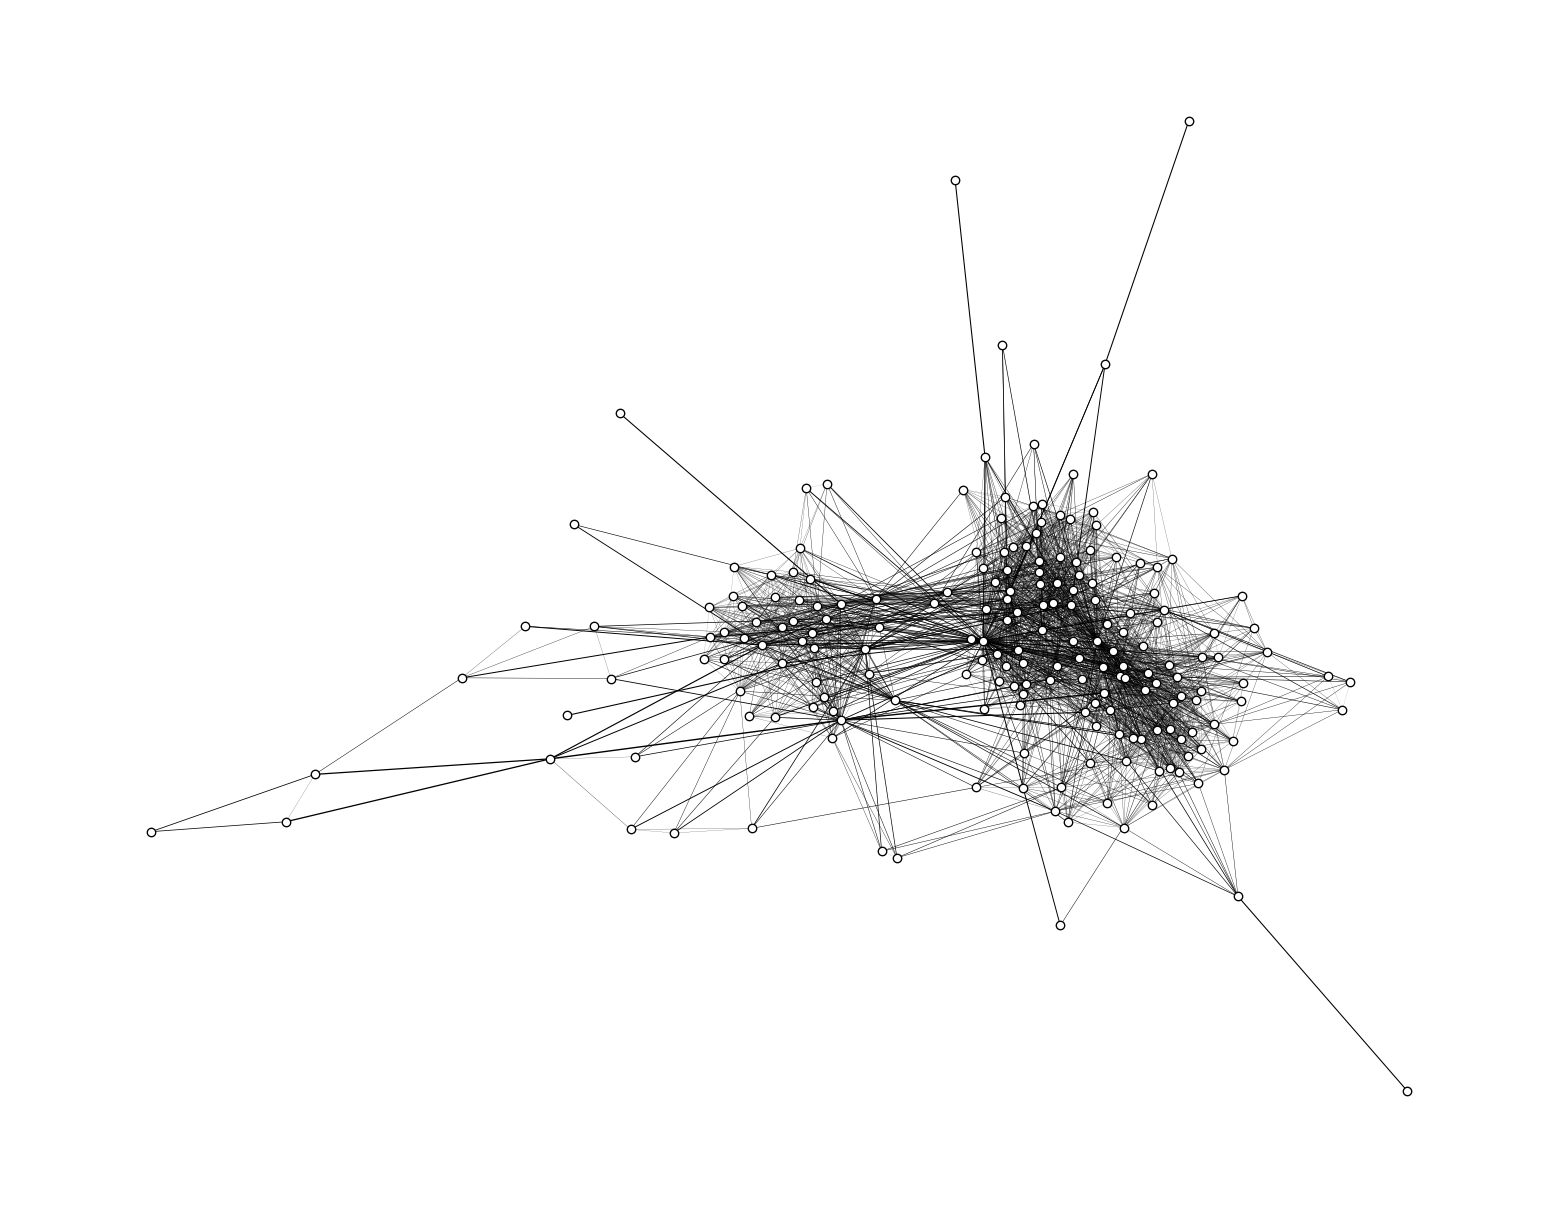

In [57]:
fig, ax = plt.subplots(figsize=(8,8))

nx.draw_networkx_edges(network, pos=pos, width=edge_widths)
nx.draw_networkx_nodes(network, pos=pos, node_color='white', edgecolors='black', linewidths=0.5, node_size=10)

ax.set_axis_off()
ax.set_aspect('equal')

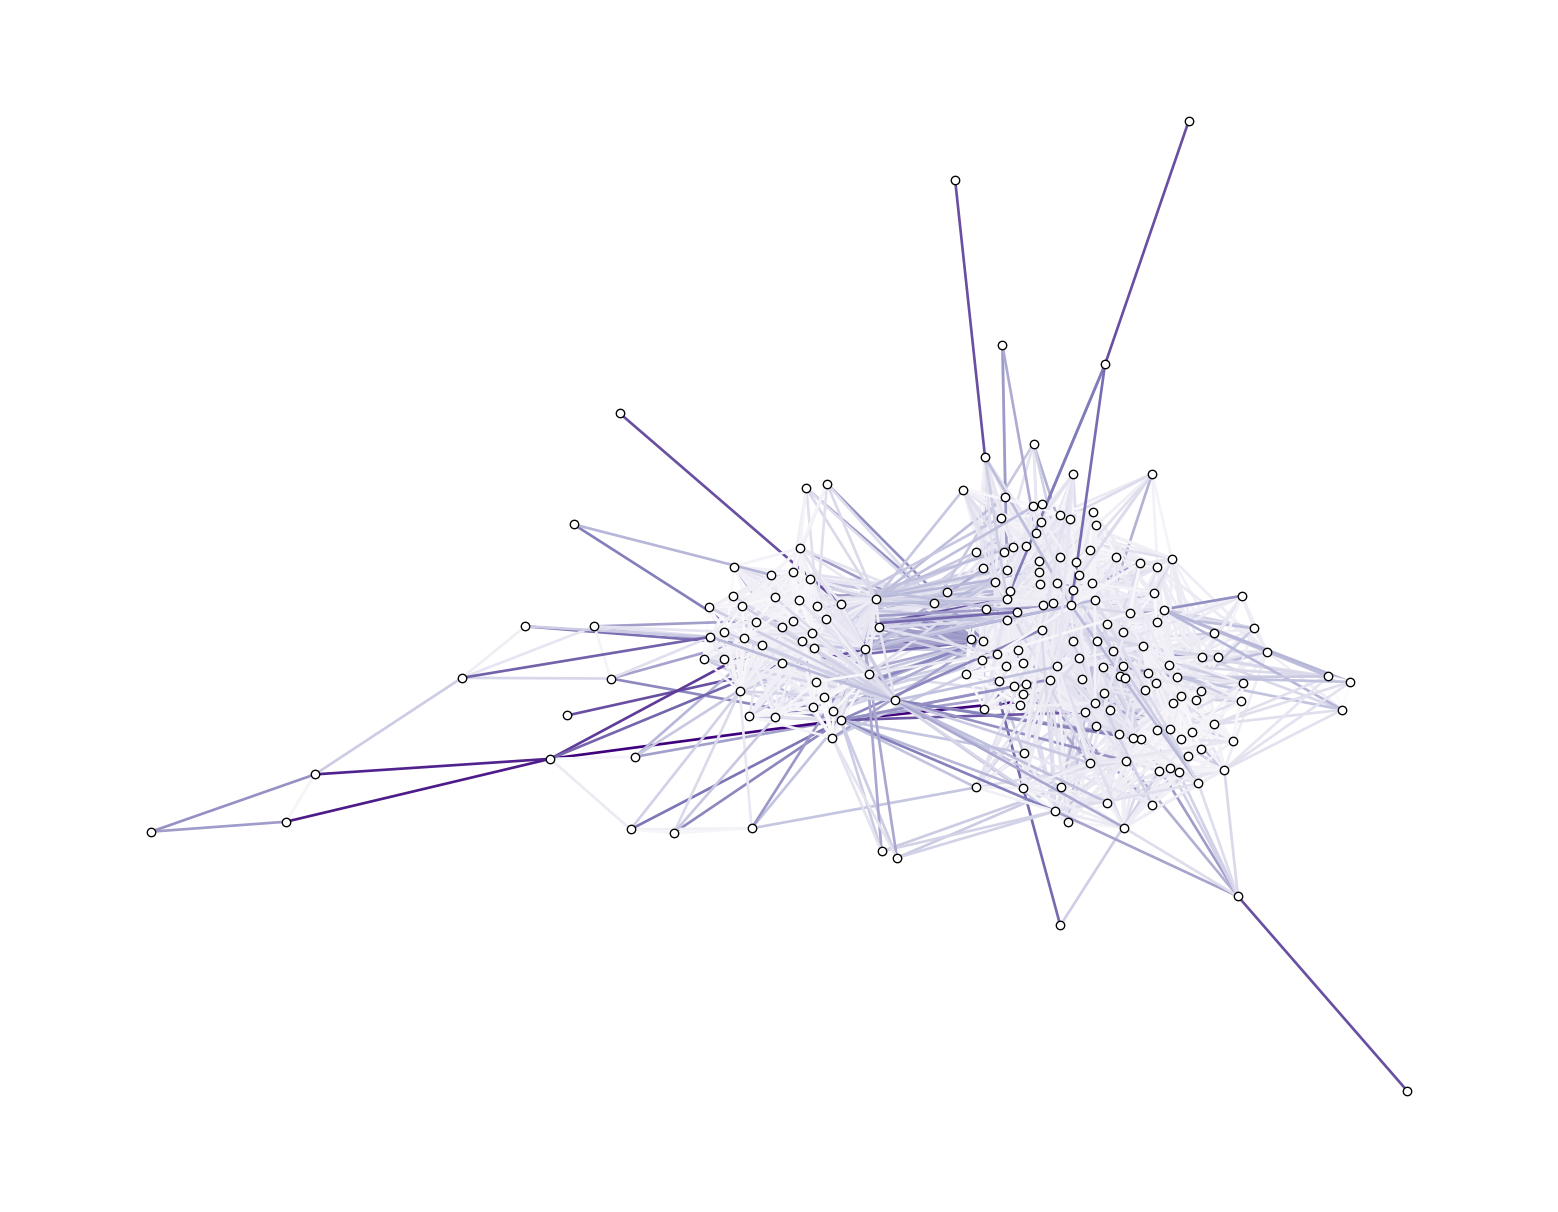

In [59]:
fig, ax = plt.subplots(figsize=(8, 8))

nx.draw_networkx_edges(
    network,
    pos=pos,
    edge_color=edge_widths,
    edge_cmap=sns.color_palette("Purples", as_cmap=True),
)
nx.draw_networkx_nodes(
    network,
    pos=pos,
    node_color="white",
    edgecolors="black",
    linewidths=0.5,
    node_size=10,
)

ax.set_axis_off()
ax.set_aspect("equal")

In [61]:
centrality = nx.pagerank(network)
centrality

{1: 0.0039177099627276946,
 11: 0.0063519460181661255,
 12: 0.007047489256881568,
 13: 0.009258208895333913,
 14: 0.00753188896932636,
 15: 0.007529994825749731,
 16: 0.004099614050456388,
 17: 0.00395226593900831,
 18: 0.009066165590812001,
 19: 0.00848212653204664,
 2: 0.00363276109166039,
 20: 0.011222183867211364,
 21: 0.006775588255790336,
 22: 0.0023304006996265362,
 23: 0.011467385102069282,
 24: 0.0071170249146954336,
 3: 0.005213534117834577,
 4: 0.006775588255790336,
 5: 0.0025531638136968766,
 6: 0.004024400687443473,
 7: 0.01455463058532136,
 8: 0.0036716403708687445,
 9: 0.004668855664340586,
 120: 0.003152877488703934,
 121: 0.006694759994268096,
 122: 0.006915049929724576,
 123: 0.006566910658370133,
 124: 0.00525241267849153,
 125: 0.008415236789436236,
 67: 0.016580046244867884,
 10: 0.0067157459082754405,
 130: 0.00394859138921337,
 145: 0.002096096476935373,
 146: 0.0022581528228233284,
 147: 0.002096096476935373,
 148: 0.004689878992056279,
 149: 0.00764362014368536

In [71]:
node_size = [np.sqrt(centrality[n]) * 500 for n in network.nodes()]
node_size

[np.float64(31.29580627946696),
 np.float64(39.84954836057156),
 np.float64(41.9746627648203),
 np.float64(48.109793429544865),
 np.float64(43.393228069960294),
 np.float64(43.38777139284101),
 np.float64(32.01411427189728),
 np.float64(31.4335248540802),
 np.float64(47.608207251512844),
 np.float64(46.049230536586165),
 np.float64(30.136195395489086),
 np.float64(52.96740475804757),
 np.float64(41.156980743825024),
 np.float64(24.137111983554163),
 np.float64(53.54293861488479),
 np.float64(42.18123076290992),
 np.float64(36.10240337510294),
 np.float64(41.156980743825024),
 np.float64(25.26442070232799),
 np.float64(31.71908214089538),
 np.float64(60.32128684246002),
 np.float64(30.29703108750404),
 np.float64(34.164512525208764),
 np.float64(28.075244828424623),
 np.float64(40.91075651423503),
 np.float64(41.578389608438954),
 np.float64(40.51823866597033),
 np.float64(36.23676544095627),
 np.float64(45.867299869940666),
 np.float64(64.38176419776777),
 np.float64(40.97482735862178)

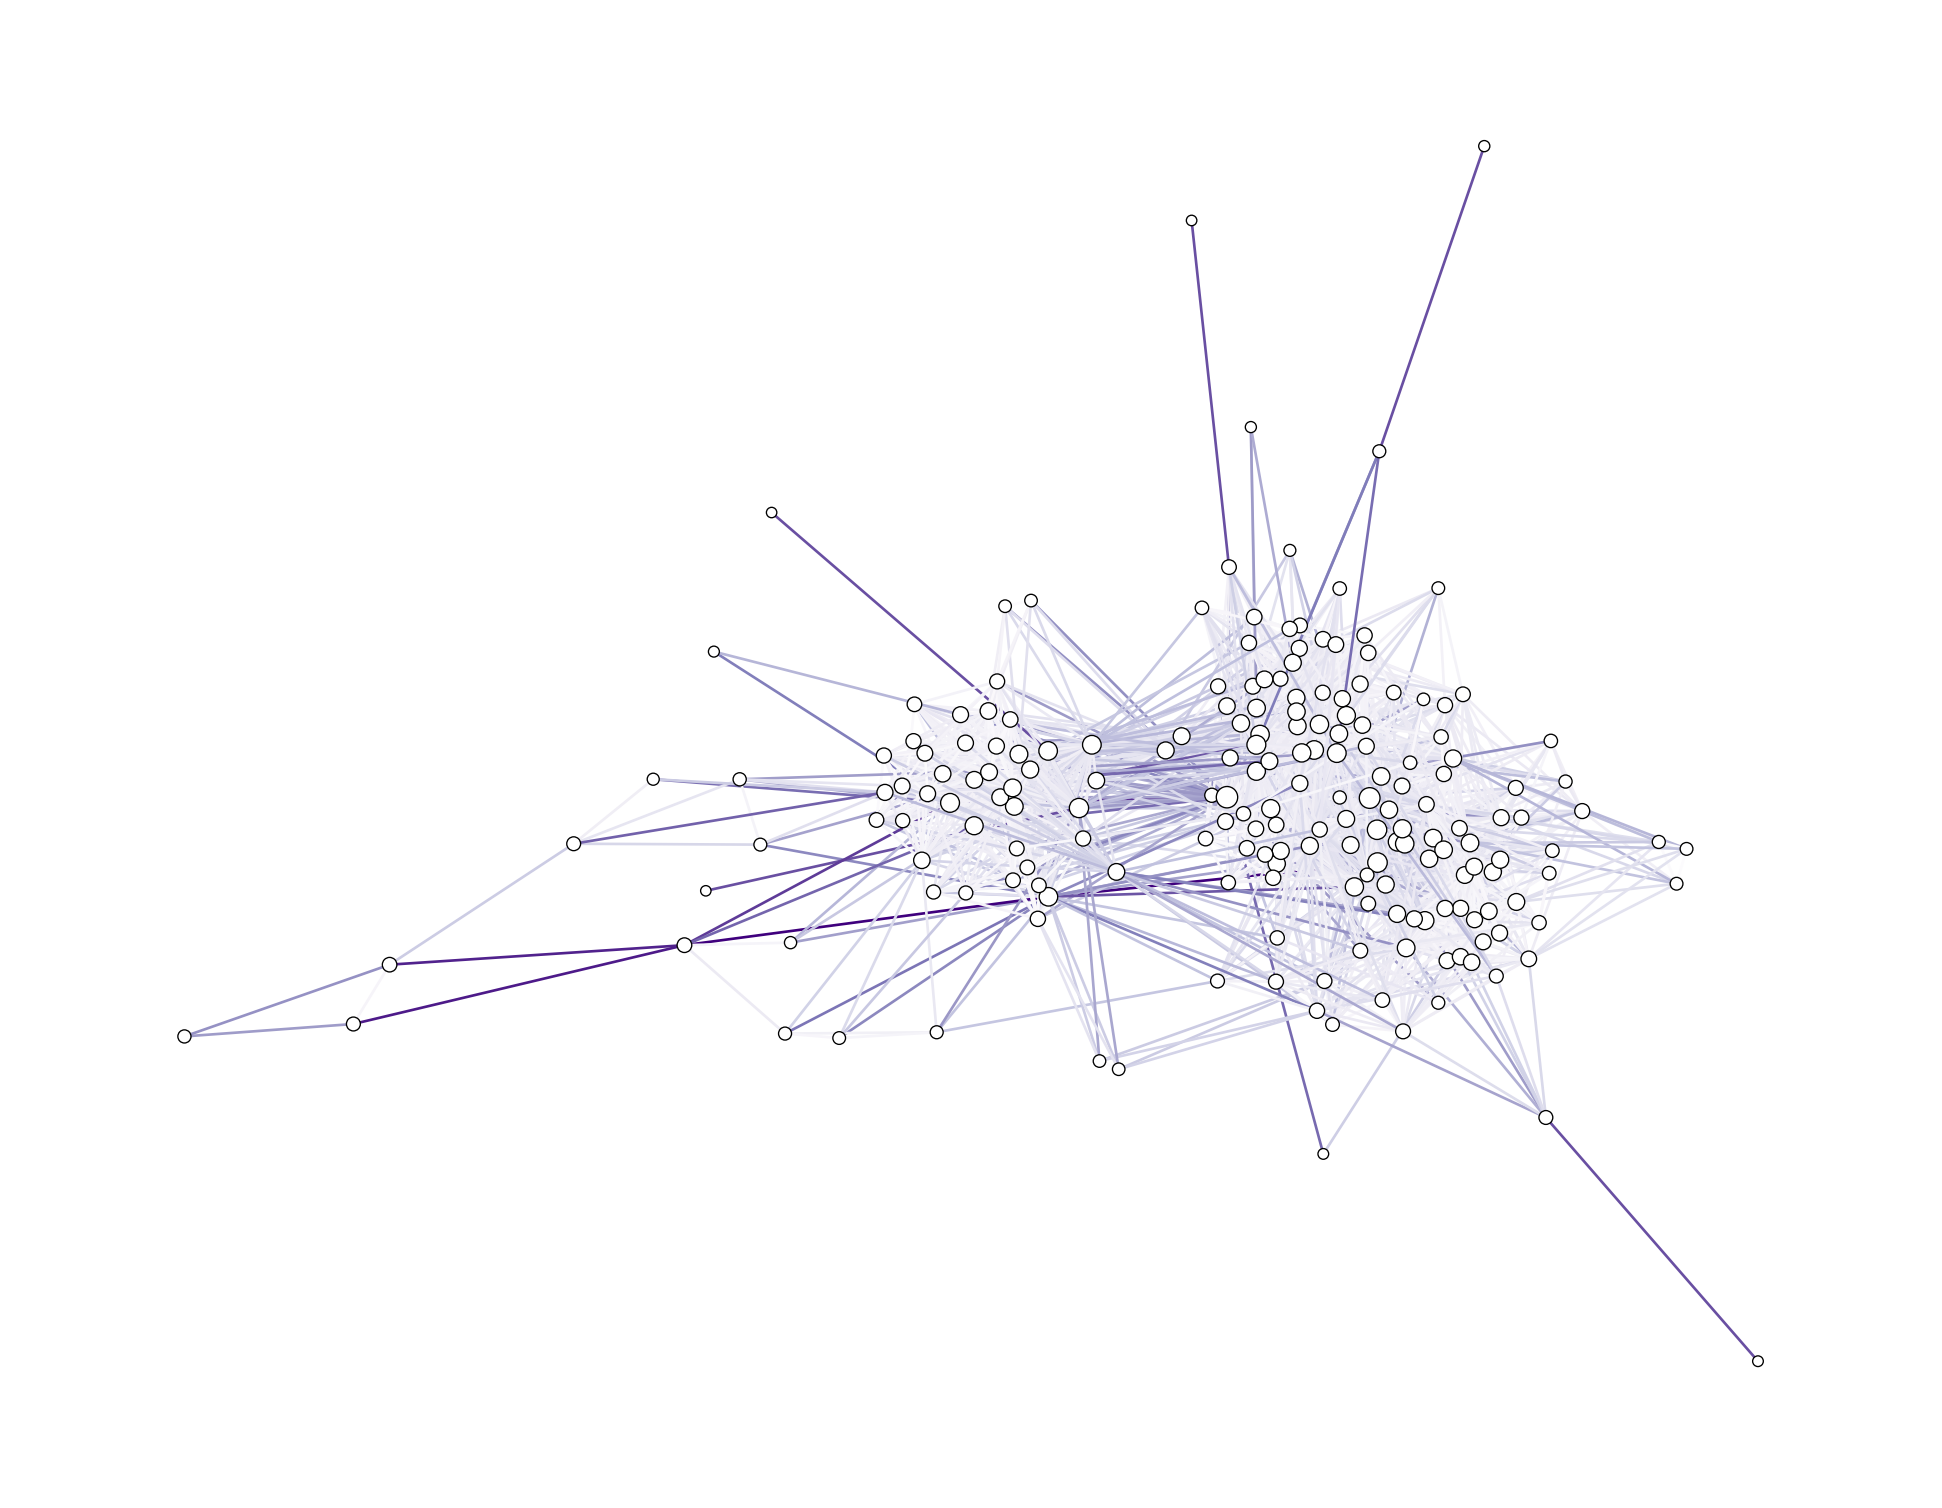

In [73]:
fig, ax = plt.subplots(figsize=(10, 10))

nx.draw_networkx_edges(
    network,
    pos=pos,
    edge_color=edge_widths,
    edge_cmap=sns.color_palette("Purples", as_cmap=True),
)
nx.draw_networkx_nodes(
    network,
    pos=pos,
    node_color="white",
    edgecolors="black",
    linewidths=0.5,
    node_size=node_size,
)

ax.set_axis_off()
ax.set_aspect("equal")

In [81]:
pos_force = nx.forceatlas2_layout(network)

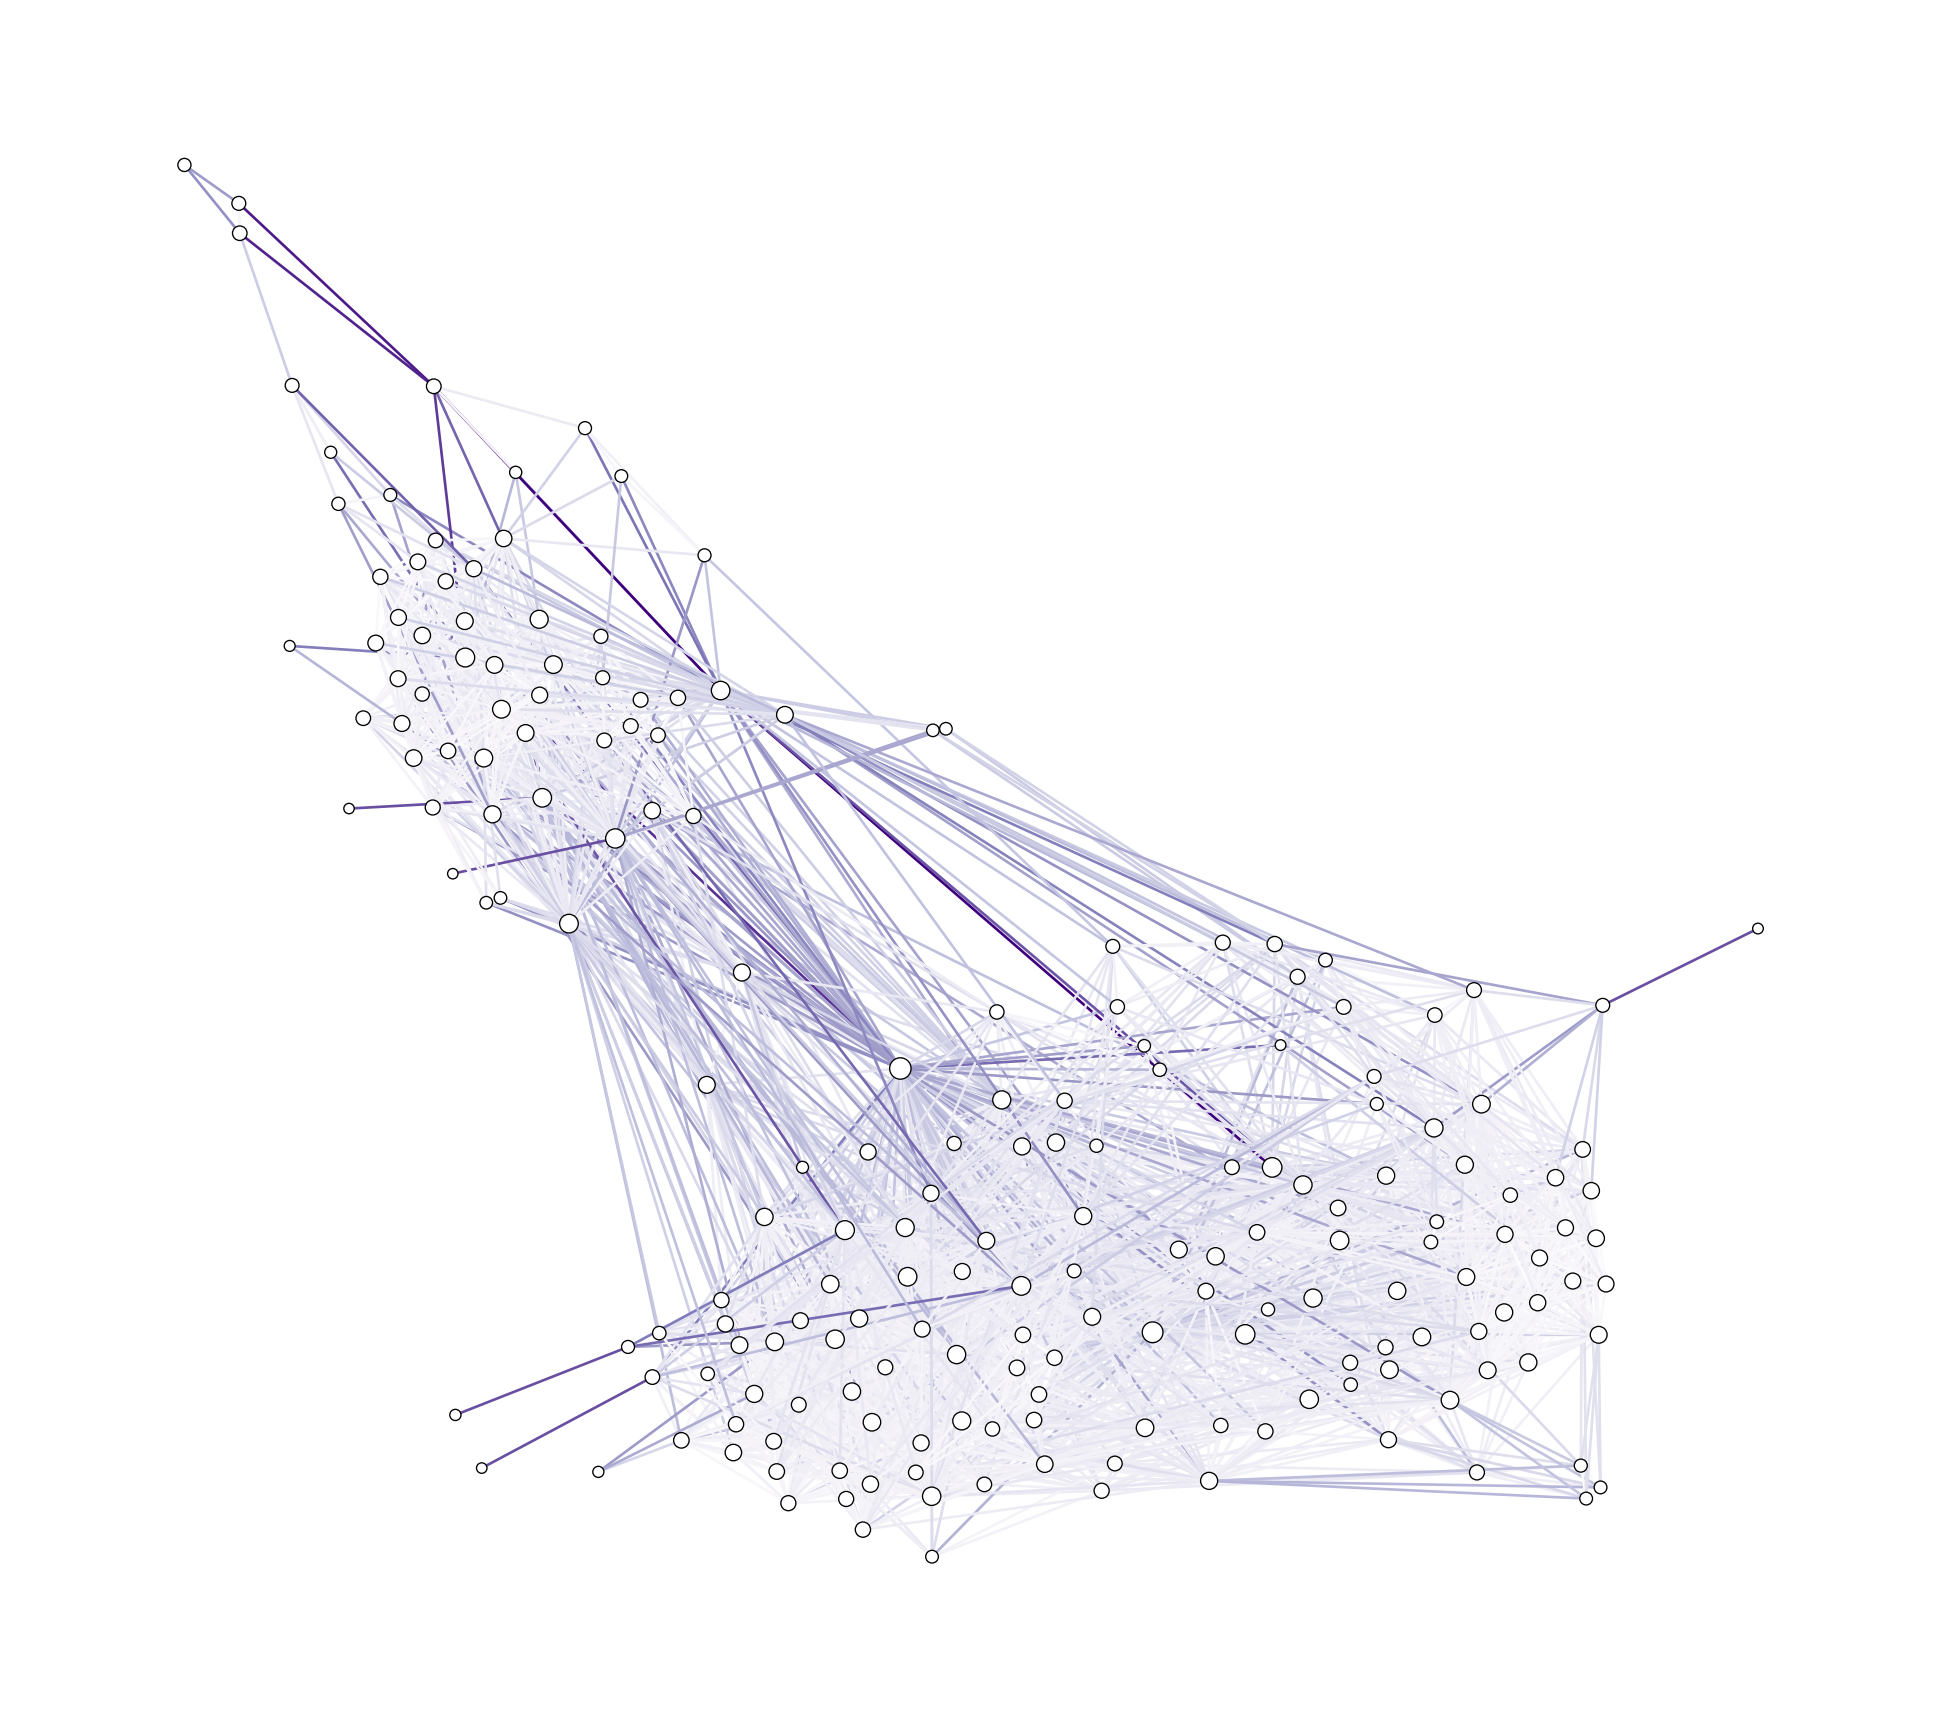

In [82]:
fig, ax = plt.subplots(figsize=(10, 10))

nx.draw_networkx_edges(
    network,
    pos=pos_force,
    edge_color=edge_widths,
    edge_cmap=sns.color_palette("Purples", as_cmap=True),
)
nx.draw_networkx_nodes(
    network,
    pos=pos_force,
    node_color="white",
    edgecolors="black",
    linewidths=0.5,
    node_size=node_size,
)

ax.set_axis_off()
ax.set_aspect("equal")

In [114]:
import random

src = random.randint(1, network.number_of_nodes())
dst = random.randint(1, network.number_of_nodes())

src, dst

(87, 82)

In [118]:
shortest_path = nx.shortest_path(network, 193, 45)
shortest_path

[193, 67, 32, 45]

In [119]:
path_edges = list(zip(shortest_path[:-1], shortest_path[1:]))
path_edges

[(193, 67), (67, 32), (32, 45)]

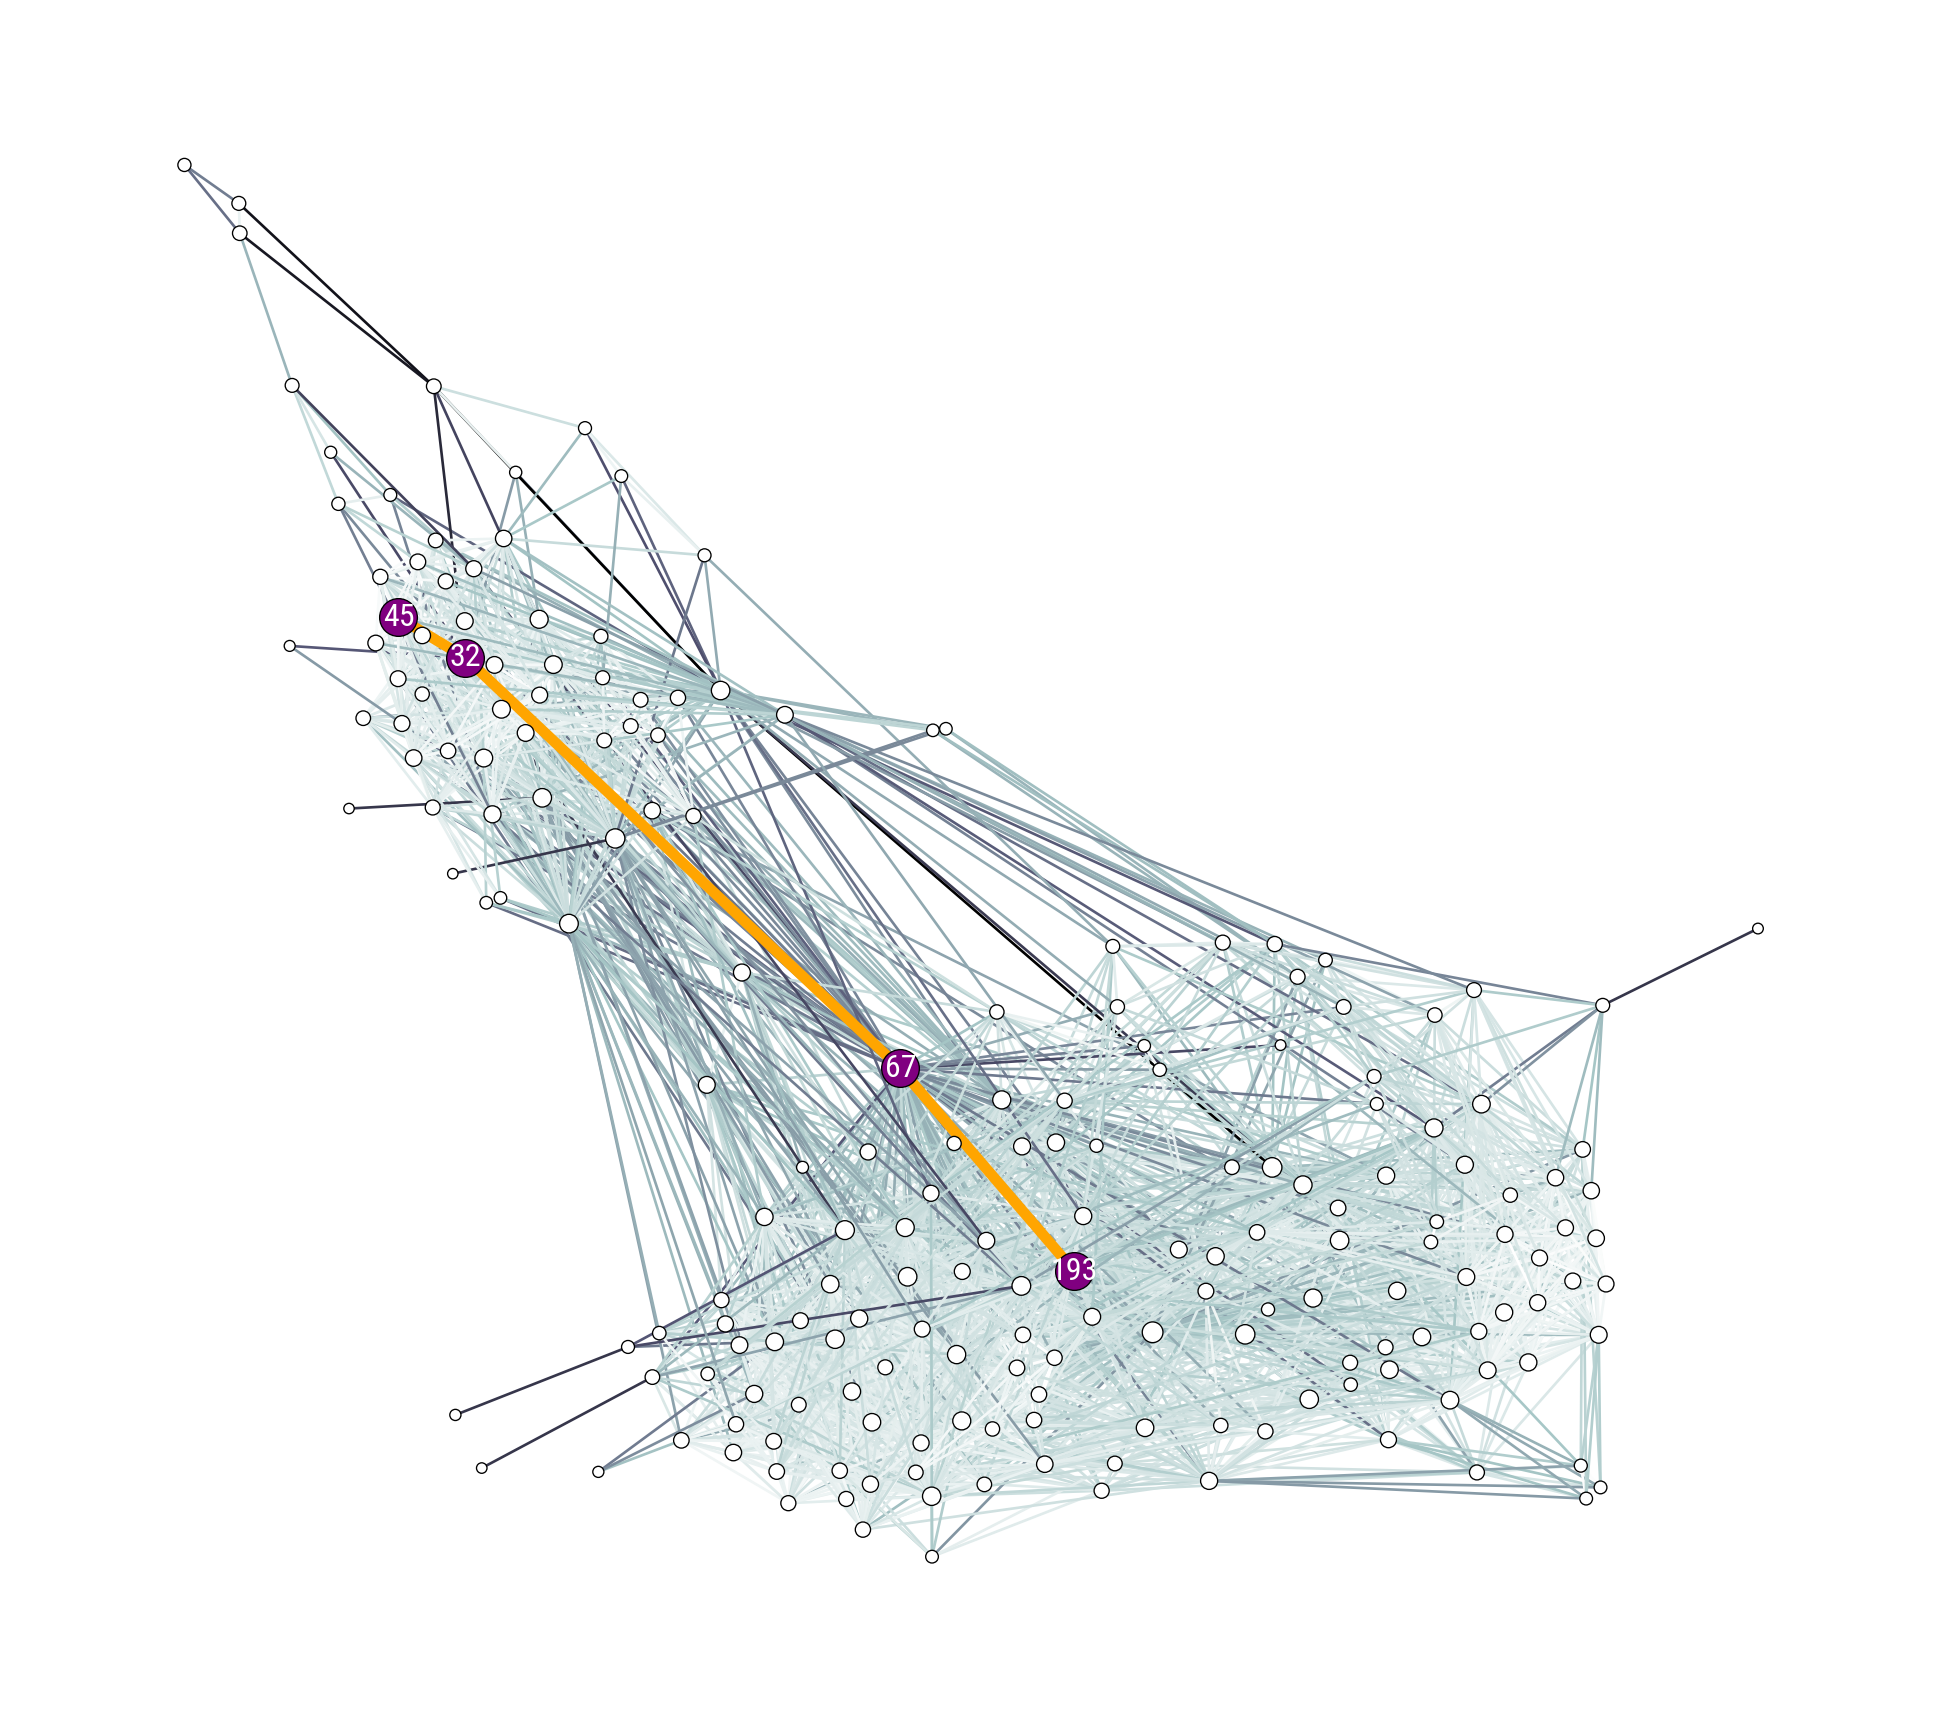

In [120]:
fig, ax = plt.subplots(figsize=(10, 10))

# red base
nx.draw_networkx_edges(
    network,
    pos=pos_force,
    edge_color=edge_widths,
    edge_cmap=sns.color_palette("bone_r", as_cmap=True),
)
nx.draw_networkx_nodes(
    network,
    pos=pos_force,
    node_color="white",
    edgecolors="black",
    linewidths=0.5,
    node_size=node_size,
)

# camino

nx.draw_networkx_edges(
    network,
    edgelist=path_edges,
    pos=pos_force,
    edge_color="orange",
    edge_cmap=sns.color_palette("bone_r", as_cmap=True),
    width=4,
)
nx.draw_networkx_nodes(
    network,
    pos=pos_force,
    nodelist=shortest_path,
    node_color="purple",
    edgecolors="black",
    linewidths=0.5,
    node_size=200,
)
nx.draw_networkx_labels(
    network,
    pos=pos_force,
    labels=dict(zip(shortest_path, shortest_path)),
    font_color="white",
)

ax.set_axis_off()
ax.set_aspect("equal")